# 🐜 SightRAG — Image and Video RAG
## See. Search. Retrieve.

[![PyPI](https://img.shields.io/pypi/v/sightrag)](https://pypi.org/project/sightrag/)
[![License](https://img.shields.io/badge/license-Apache%202.0-blue)](https://github.com/VK-Ant/sightrag)

Search your images and videos with plain English. Three lines of code.

**GitHub:** [VK-Ant/sightrag](https://github.com/VK-Ant/sightrag) | **Author:** Ant (VK-Ant)

---

### This notebook tests all input modes:
1. Image folder indexing
2. Text queries
3. Reference image queries
4. Camera capture (webcam)
5. Upload your own images
6. Visualization with bounding boxes

## Step 1 — Install SightRAG

In [1]:
!pip install sightrag -q

from sightrag import SightRAG, __version__
print(f'\n✅ SightRAG v{__version__} installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.5 MB/s eta 0:00:00

✅ SightRAG v0.1.0 installed


## Step 2 — Create Demo Data

- For Fast Testing purpose: Creating input images, reference images, and folder structure.
- If you have own data - Create the folder and test it accordingly

✅ Demo data created:
   Input images:     6 files
   Reference images: 3 files


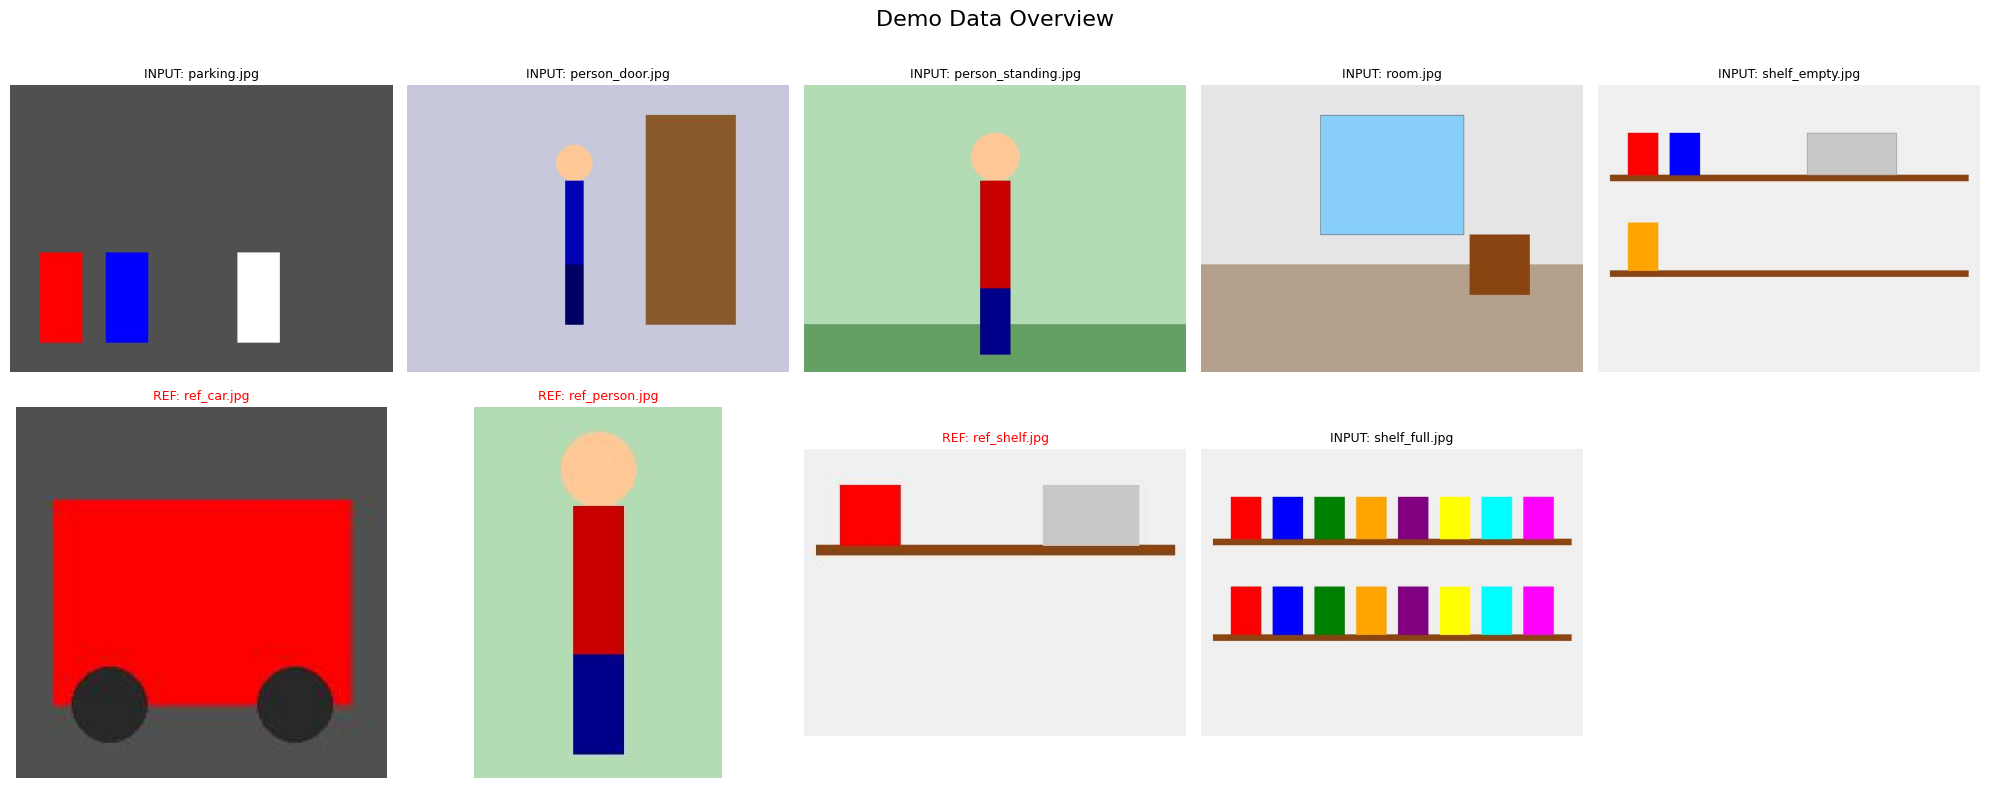

In [2]:
from PIL import Image, ImageDraw
import os

# Create folder structure
for d in ['demo_sightrag/input_images', 'demo_sightrag/reference_images',
          'demo_sightrag/camera_captures', 'demo_sightrag/video_samples']:
    os.makedirs(d, exist_ok=True)

# ── INPUT IMAGES (6 images to index) ──

# Shelf with empty space
img = Image.new('RGB', (640, 480), (240, 240, 240))
draw = ImageDraw.Draw(img)
draw.rectangle([20, 150, 620, 160], fill=(139, 69, 19))
draw.rectangle([20, 310, 620, 320], fill=(139, 69, 19))
draw.rectangle([50, 80, 100, 150], fill=(255, 0, 0))
draw.rectangle([120, 80, 170, 150], fill=(0, 0, 255))
draw.rectangle([350, 80, 500, 150], fill=(200, 200, 200), outline=(150,150,150))
draw.rectangle([50, 230, 100, 310], fill=(255, 165, 0))
img.save('demo_sightrag/input_images/shelf_empty.jpg')

# Shelf fully stocked
img = Image.new('RGB', (640, 480), (240, 240, 240))
draw = ImageDraw.Draw(img)
draw.rectangle([20, 150, 620, 160], fill=(139, 69, 19))
draw.rectangle([20, 310, 620, 320], fill=(139, 69, 19))
colors = [(255,0,0),(0,0,255),(0,128,0),(255,165,0),(128,0,128),(255,255,0),(0,255,255),(255,0,255)]
for i in range(8):
    x = 50 + i * 70
    draw.rectangle([x, 80, x+50, 150], fill=colors[i])
    draw.rectangle([x, 230, x+50, 310], fill=colors[i])
img.save('demo_sightrag/input_images/shelf_full.jpg')

# Person near door
img = Image.new('RGB', (640, 480), (200, 200, 220))
draw = ImageDraw.Draw(img)
draw.rectangle([400, 50, 550, 400], fill=(139, 90, 43))
draw.ellipse([250, 100, 310, 160], fill=(255, 200, 150))
draw.rectangle([265, 160, 295, 300], fill=(0, 0, 180))
draw.rectangle([265, 300, 295, 400], fill=(0, 0, 100))
img.save('demo_sightrag/input_images/person_door.jpg')

# Person standing
img = Image.new('RGB', (640, 480), (180, 220, 180))
draw = ImageDraw.Draw(img)
draw.rectangle([0, 400, 640, 480], fill=(100, 160, 100))
draw.ellipse([280, 80, 360, 160], fill=(255, 200, 150))
draw.rectangle([295, 160, 345, 340], fill=(200, 0, 0))
draw.rectangle([295, 340, 345, 450], fill=(0, 0, 139))
img.save('demo_sightrag/input_images/person_standing.jpg')

# Parking lot
img = Image.new('RGB', (640, 480), (80, 80, 80))
draw = ImageDraw.Draw(img)
draw.rectangle([50, 280, 120, 430], fill=(255, 0, 0))
draw.rectangle([160, 280, 230, 430], fill=(0, 0, 255))
draw.rectangle([380, 280, 450, 430], fill=(255, 255, 255))
img.save('demo_sightrag/input_images/parking.jpg')

# Room
img = Image.new('RGB', (640, 480), (230, 230, 230))
draw = ImageDraw.Draw(img)
draw.polygon([(0, 300), (640, 300), (640, 480), (0, 480)], fill=(180, 160, 140))
draw.rectangle([200, 50, 440, 250], fill=(135, 206, 250), outline=(100, 100, 100))
draw.rectangle([450, 250, 550, 350], fill=(139, 69, 19))
img.save('demo_sightrag/input_images/room.jpg')

# ── REFERENCE IMAGES (3 query images) ──

# Reference shelf
img = Image.new('RGB', (320, 240), (240, 240, 240))
draw = ImageDraw.Draw(img)
draw.rectangle([10, 80, 310, 88], fill=(139, 69, 19))
draw.rectangle([30, 30, 80, 80], fill=(255, 0, 0))
draw.rectangle([200, 30, 280, 80], fill=(200, 200, 200))
img.save('demo_sightrag/reference_images/ref_shelf.jpg')

# Reference person
img = Image.new('RGB', (200, 300), (180, 220, 180))
draw = ImageDraw.Draw(img)
draw.ellipse([70, 20, 130, 80], fill=(255, 200, 150))
draw.rectangle([80, 80, 120, 200], fill=(200, 0, 0))
draw.rectangle([80, 200, 120, 280], fill=(0, 0, 139))
img.save('demo_sightrag/reference_images/ref_person.jpg')

# Reference car
img = Image.new('RGB', (200, 200), (80, 80, 80))
draw = ImageDraw.Draw(img)
draw.rectangle([20, 50, 180, 160], fill=(255, 0, 0))
draw.ellipse([30, 140, 70, 180], fill=(40, 40, 40))
draw.ellipse([130, 140, 170, 180], fill=(40, 40, 40))
img.save('demo_sightrag/reference_images/ref_car.jpg')

print('✅ Demo data created:')
print(f'   Input images:     {len(os.listdir("demo_sightrag/input_images"))} files')
print(f'   Reference images: {len(os.listdir("demo_sightrag/reference_images"))} files')

# Show all images
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Demo Data Overview', fontsize=16)

# Input images
input_imgs = sorted(os.listdir('demo_sightrag/input_images'))
for i, (ax, f) in enumerate(zip(axes[0], input_imgs[:5])):
    ax.imshow(Image.open(f'demo_sightrag/input_images/{f}'))
    ax.set_title(f'INPUT: {f}', fontsize=9)
    ax.axis('off')
axes[0][0].set_ylabel('Input Images', fontsize=12)

# Reference images + remaining input
ref_imgs = sorted(os.listdir('demo_sightrag/reference_images'))
for i, (ax, f) in enumerate(zip(axes[1][:3], ref_imgs)):
    ax.imshow(Image.open(f'demo_sightrag/reference_images/{f}'))
    ax.set_title(f'REF: {f}', fontsize=9, color='red')
    ax.axis('off')
if len(input_imgs) > 5:
    axes[1][3].imshow(Image.open(f'demo_sightrag/input_images/{input_imgs[5]}'))
    axes[1][3].set_title(f'INPUT: {input_imgs[5]}', fontsize=9)
    axes[1][3].axis('off')
else:
    axes[1][3].axis('off')
axes[1][4].axis('off')
axes[1][0].set_ylabel('Reference Images', fontsize=12)

plt.tight_layout()
plt.show()

## Step 3 — Index Input Images

Three lines. That's all.

In [3]:
from sightrag import SightRAG

rag = SightRAG()
rag.index('./demo_sightrag/input_images/')

print(f'\n📊 Status: {rag}')

[SightRAG] Initializing...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

[SightRAG] Ready.
[SightRAG] Found 6 images, 0 videos
  [████████████████████████████████████████] 6/6 images
[SightRAG] Done. 6 regions indexed.

📊 Status: SightRAG(store='sqlite', indexed=6 regions)


## Step 4 — Text Queries

In [4]:
queries = [
    'find person',
    'find empty shelf',
    'find car in parking lot',
    'find room with furniture',
    'find person near door'
]

for q in queries:
    results = rag.query(q, top_k=2)
    print(f'\n🔍 "{q}"')
    for i, r in enumerate(results, 1):
        print(f"   {i}. {r['image_path'].split('/')[-1]} — score: {r['score']:.4f} | {r['label']}")


🔍 "find person"
   1. room.jpg — score: 0.2428 | whole_image
   2. person_standing.jpg — score: 0.2418 | whole_image

🔍 "find empty shelf"
   1. room.jpg — score: 0.2637 | whole_image
   2. shelf_full.jpg — score: 0.2549 | whole_image

🔍 "find car in parking lot"
   1. room.jpg — score: 0.2223 | whole_image
   2. parking.jpg — score: 0.2216 | whole_image

🔍 "find room with furniture"
   1. room.jpg — score: 0.2579 | whole_image
   2. person_door.jpg — score: 0.2355 | whole_image

🔍 "find person near door"
   1. room.jpg — score: 0.2434 | whole_image
   2. person_door.jpg — score: 0.2370 | whole_image


## Step 5 — Reference Image Queries

Use a reference image instead of text to find similar content.

In [5]:
import os

ref_dir = './demo_sightrag/reference_images'
ref_images = sorted([f for f in os.listdir(ref_dir) if f.endswith('.jpg')])

for ref in ref_images:
    ref_path = os.path.join(ref_dir, ref)
    results = rag.query(reference=ref_path, top_k=3)
    print(f'\n🖼️ Reference: {ref}')
    for i, r in enumerate(results, 1):
        print(f"   {i}. {r['image_path'].split('/')[-1]} — score: {r['score']:.4f}")


🖼️ Reference: ref_car.jpg
   1. parking.jpg — score: 0.7516
   2. room.jpg — score: 0.7240
   3. shelf_full.jpg — score: 0.7033

🖼️ Reference: ref_person.jpg
   1. person_standing.jpg — score: 0.9251
   2. person_door.jpg — score: 0.8699
   3. parking.jpg — score: 0.8598

🖼️ Reference: ref_shelf.jpg
   1. shelf_empty.jpg — score: 0.9023
   2. parking.jpg — score: 0.8598
   3. person_door.jpg — score: 0.8263


## Step 6 — Visualize Results with Bounding Boxes

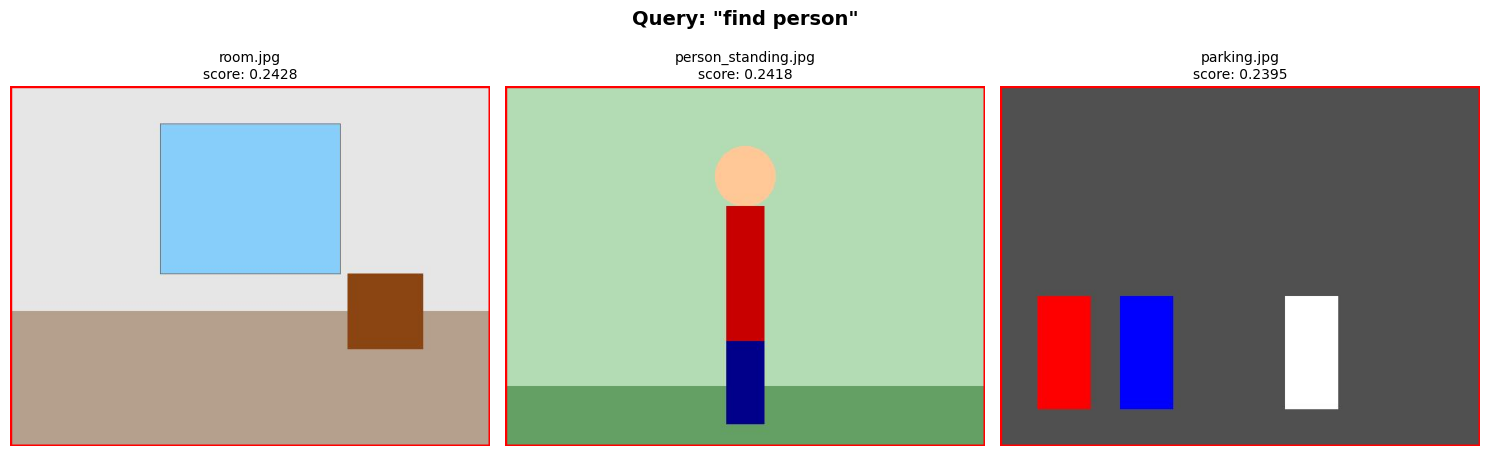

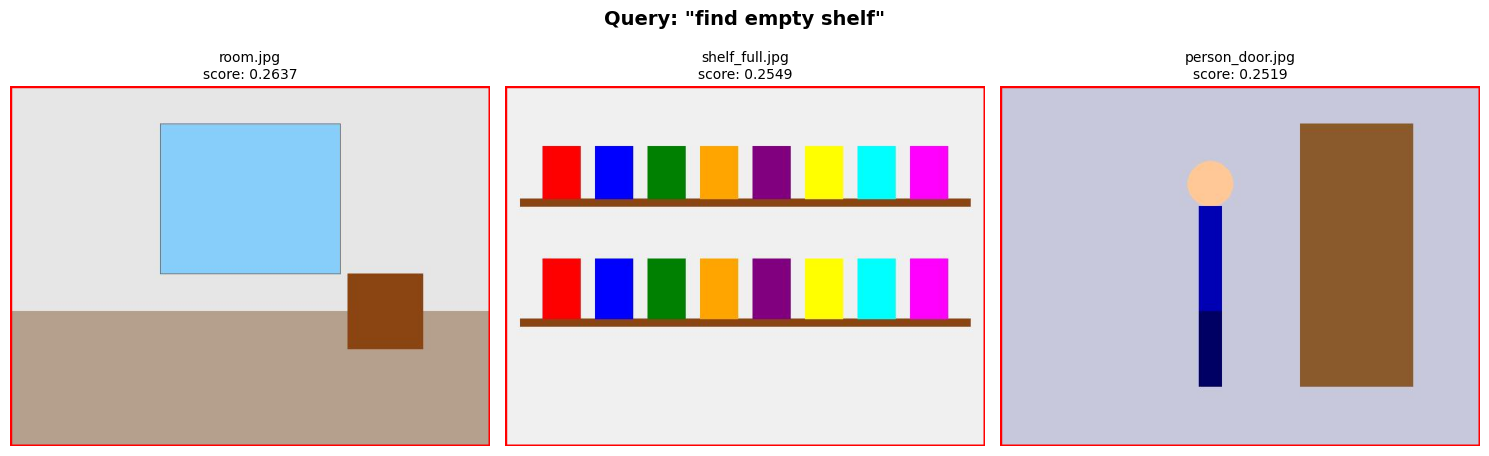

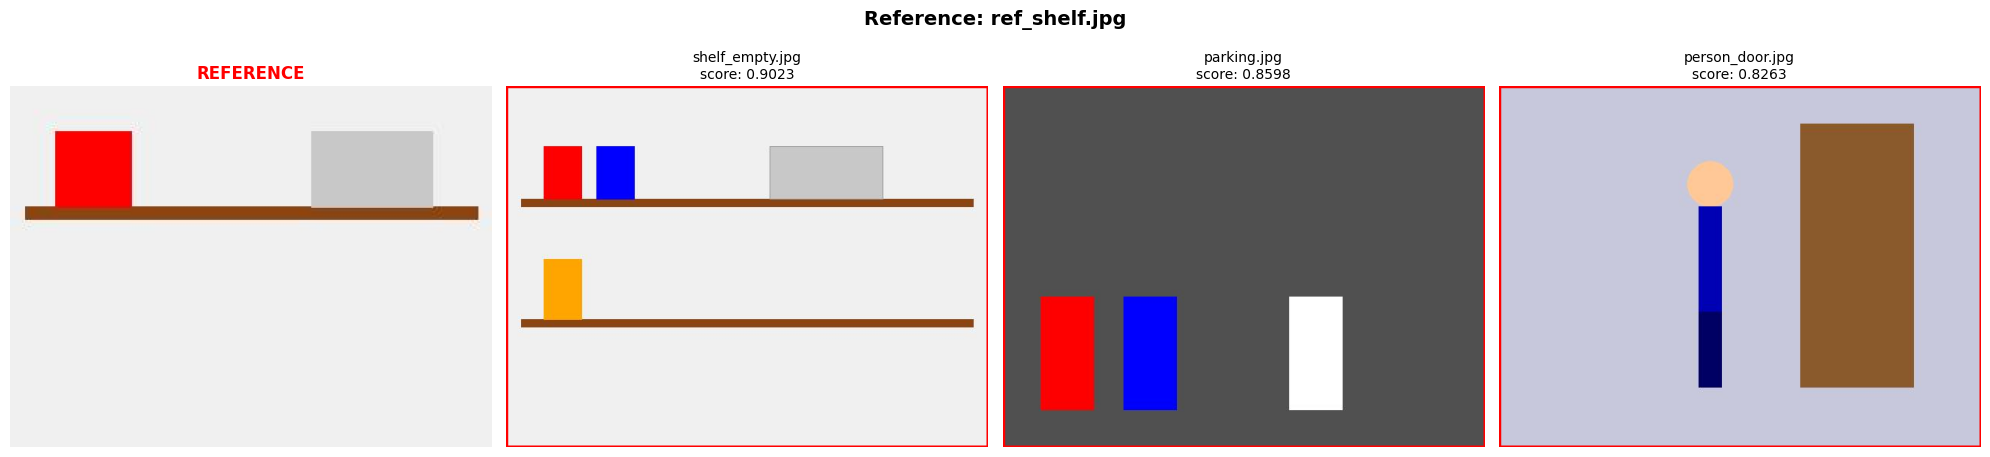

In [6]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def visualize(query_text, results, ref_img=None, max_show=3):
    n = min(len(results), max_show)
    cols = n + (1 if ref_img else 0)
    fig, axes = plt.subplots(1, cols, figsize=(5*cols, 5))
    if cols == 1: axes = [axes]

    start = 0
    if ref_img:
        axes[0].imshow(Image.open(ref_img))
        axes[0].set_title('REFERENCE', fontsize=12, color='red', fontweight='bold')
        axes[0].axis('off')
        start = 1

    for idx, r in enumerate(results[:n]):
        ax = axes[start + idx]
        img = Image.open(r['image_path']).copy()
        draw = ImageDraw.Draw(img)
        bbox = r['bbox']
        if bbox and len(bbox) == 4:
            draw.rectangle(bbox, outline='red', width=3)
            draw.text((bbox[0]+2, bbox[1]-12),
                     f"{r['label']} ({r['score']:.2f})", fill='red')
        ax.imshow(img)
        ax.set_title(f"{r['image_path'].split('/')[-1]}\nscore: {r['score']:.4f}", fontsize=10)
        ax.axis('off')

    title = f'Query: "{query_text}"' if not ref_img else f'Reference: {ref_img.split("/")[-1]}'
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Text query visualizations
visualize('find person', rag.query('find person', top_k=3))
visualize('find empty shelf', rag.query('find empty shelf', top_k=3))

# Reference image visualization
ref_path = './demo_sightrag/reference_images/ref_shelf.jpg'
visualize('', rag.query(reference=ref_path, top_k=3), ref_img=ref_path)

## Step 7 — Camera Capture (Colab Webcam)

Capture a photo from your webcam and use it as a query.

In [7]:
# Colab webcam capture
try:
    from google.colab import output
    from IPython.display import display, Javascript, HTML
    from google.colab.output import eval_js
    from base64 import b64decode
    import numpy as np
    import cv2

    js_code = '''
    async function takePhoto() {
      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      await new Promise(r => setTimeout(r, 2000));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      return canvas.toDataURL('image/jpeg', 0.8);
    }
    '''
    display(Javascript(js_code))
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])

    cam_path = 'demo_sightrag/camera_captures/webcam_capture.jpg'
    with open(cam_path, 'wb') as f:
        f.write(binary)

    print('✅ Webcam photo captured!')

    # Show captured image
    plt.figure(figsize=(6, 4))
    plt.imshow(Image.open(cam_path))
    plt.title('Webcam Capture')
    plt.axis('off')
    plt.show()

    # Use as reference query
    results = rag.query(reference=cam_path, top_k=3)
    print(f'\n🔍 Results using webcam photo as reference:')
    for i, r in enumerate(results, 1):
        print(f"   {i}. {r['image_path'].split('/')[-1]} — score: {r['score']:.4f}")

    visualize('', results, ref_img=cam_path)

except Exception as e:
    print(f'⚠️ Camera not available in this environment: {e}')
    print('   This is normal for some Colab runtimes.')
    print('   Try locally with: rag.index(source="camera")')

<IPython.core.display.Javascript object>

⚠️ Camera not available in this environment: NotAllowedError: The request is not allowed by the user agent or the platform in the current context.
   This is normal for some Colab runtimes.
   Try locally with: rag.index(source="camera")


## Step 8 — Upload Your Own Images

📁 Upload your images (JPG, PNG, WebP):


Saving 41Gb6fD+5FL-2649465154.jpg to 41Gb6fD+5FL-2649465154.jpg
[SightRAG] Initializing...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[SightRAG] Ready.
[SightRAG] Found 1 images, 0 videos
  [████████████████████████████████████████] 1/1 images
[SightRAG] Done. 2 regions indexed.

🔍 Enter your search query: ball

Results for "ball":
  1. 41Gb6fD+5FL-2649465154.jpg — score: 0.2853
  2. 41Gb6fD+5FL-2649465154.jpg — score: 0.2809


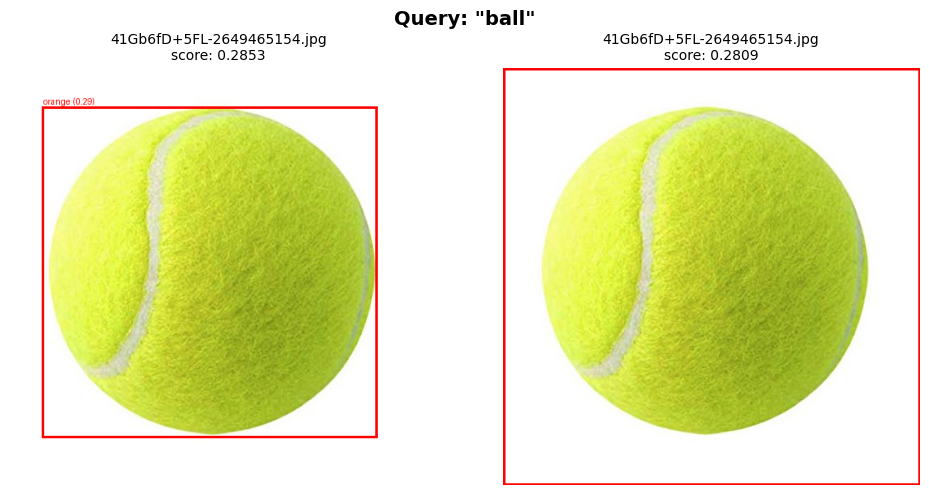

[SightRAG] Index cleared.


In [8]:
try:
    from google.colab import files

    print('📁 Upload your images (JPG, PNG, WebP):')
    uploaded = files.upload()

    os.makedirs('my_uploads', exist_ok=True)
    for name, data in uploaded.items():
        with open(f'my_uploads/{name}', 'wb') as f:
            f.write(data)

    # Create fresh index with uploaded images
    my_rag = SightRAG(index_path='./my_upload_index')
    my_rag.index('./my_uploads/')

    # Interactive query
    query = input('\n🔍 Enter your search query: ')
    results = my_rag.query(query, top_k=3)

    print(f'\nResults for "{query}":')
    for i, r in enumerate(results, 1):
        print(f"  {i}. {r['image_path'].split('/')[-1]} — score: {r['score']:.4f}")

    visualize(query, results)
    my_rag.clear()

except ImportError:
    print('⚠️  File upload only available in Google Colab')
    print('   Locally use: rag.index("./your_folder/")')

## Step 9 — domain_hint for Custom Domains

In [9]:
# Retail domain hint
rag_retail = SightRAG(
    domain_hint='retail shelf product stock inventory empty facing',
    index_path='./retail_index'
)
rag_retail.index('./demo_sightrag/input_images/')

results = rag_retail.query('out of stock products', top_k=3)
print('🏪 Retail domain hint: "out of stock products"')
for i, r in enumerate(results, 1):
    print(f"  {i}. {r['image_path'].split('/')[-1]} — score: {r['score']:.4f}")

rag_retail.clear()

[SightRAG] Initializing...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[SightRAG] Ready.
[SightRAG] Found 6 images, 0 videos
  [████████████████████████████████████████] 6/6 images
[SightRAG] Done. 6 regions indexed.
🏪 Retail domain hint: "out of stock products"
  1. room.jpg — score: 0.2431
  2. shelf_full.jpg — score: 0.2423
  3. parking.jpg — score: 0.2302
[SightRAG] Index cleared.


SightRAG(store='sqlite', indexed=0 regions)

## Cleanup & Summary

In [10]:
import shutil

rag.clear()
for d in ['./sightrag_index', './retail_index', './my_upload_index']:
    shutil.rmtree(d, ignore_errors=True)

print('=' * 50)
print('  SightRAG Demo Complete! 🐜')
print('=' * 50)
print()
print('  Tested:')
print('  ✅ Image folder indexing')
print('  ✅ Text queries (5 queries)')
print('  ✅ Reference image queries (3 references)')
print('  ✅ Camera capture')
print('  ✅ Upload your own images')
print('  ✅ Visualization with bounding boxes')
print('  ✅ Custom domain_hint')
print()
print('  ⭐ Star: github.com/VK-Ant/sightrag')
print('  📦 Install: pip install sightrag')
print('  🐜 Built by Ant (VK-Ant)')

[SightRAG] Index cleared.
  SightRAG Demo Complete! 🐜

  Tested:
  ✅ Image folder indexing
  ✅ Text queries (5 queries)
  ✅ Reference image queries (3 references)
  ✅ Camera capture
  ✅ Upload your own images
  ✅ Visualization with bounding boxes
  ✅ Custom domain_hint

  ⭐ Star: github.com/VK-Ant/sightrag
  📦 Install: pip install sightrag
  🐜 Built by Ant (VK-Ant)
